## Core of Linear Transformations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

In [3]:
C = A @ B
print("Matrix multiplication / Transformation: \n", C) #Matrix multiplication = Transfromation

E = np.multiply(A, B)
print("Element wise multiplcation: \n", E)

Matrix multiplication / Transformation: 
 [[19 22]
 [43 50]]
Element wise multiplcation: 
 [[ 5 12]
 [21 32]]


In [4]:
#Now taking a vector and will transform it with A
V = np.array([10, 20])

C = A @ V
E = np.multiply(A, V)

print("Matrix multiplication / Transformation: \n", C) 
print("Element wise multiplcation: \n", E) #Numpy uses broadcasting here. V is taken as [[10, 20],[10, 20]]

Matrix multiplication / Transformation: 
 [ 50 110]
Element wise multiplcation: 
 [[10 40]
 [30 80]]


In [5]:
A = np.array([[2, 0], [0, 1]]) # Stretch X
B = np.array([[1, 1], [0, 1]]) # Shear

In [6]:
T1 = A @ B
T2 = B @ A

print(T1)
print(T2)

[[2 2]
 [0 1]]
[[2 1]
 [0 1]]


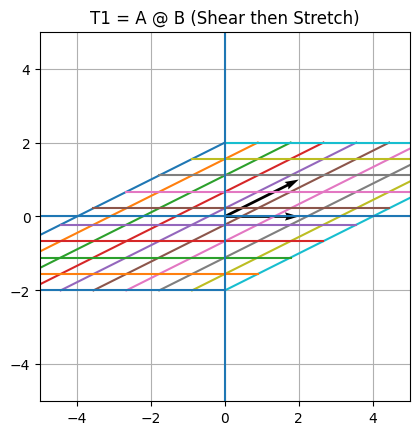

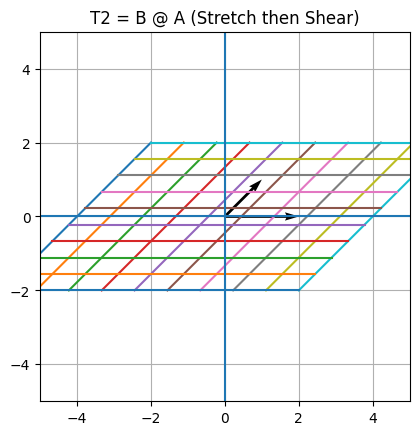

In [7]:
def plot_transformation(T, title):
    x = np.linspace(-2, 2, 10)
    y = np.linspace(-2, 2, 10)
    
    plt.figure()

    for i in x:
        pts = np.array([[i, j] for j in y])
        transformed = (T @ pts.T).T
        plt.plot(transformed[:, 0], transformed[:, 1])

    for j in y:
        pts = np.array([[i, j] for i in x])
        transformed = (T @ pts.T).T
        plt.plot(transformed[:,0], transformed[:,1])
        
    # basis vectors
    e1 = np.array([1, 0])
    e2 = np.array([0, 1])

    Te1 = T @ e1
    Te2 = T @ e2

    plt.quiver(0, 0, Te1[0], Te1[1], angles='xy', scale_units='xy', scale=1)
    plt.quiver(0, 0, Te2[0], Te2[1], angles='xy', scale_units='xy', scale=1)

    plt.axhline(0)
    plt.axvline(0)
    plt.grid()
    plt.title(title)
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)

    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

plot_transformation(T1, "T1 = A @ B (Shear then Stretch)")
plot_transformation(T2, "T2 = B @ A (Stretch then Shear)")

[2 0]
[1 1]


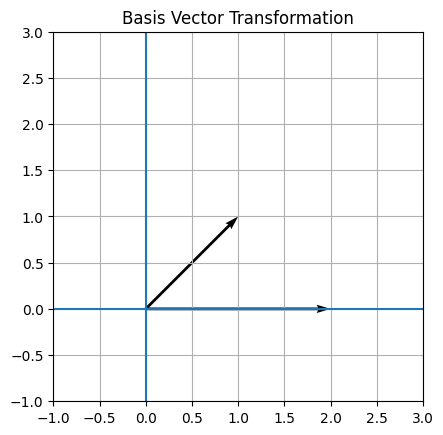

In [8]:
T = np.array([[2, 1],
              [0, 1]])

e1 = np.array([1, 0])
e2 = np.array([0, 1])

Te1 = T @ e1
Te2 = T @ e2

print(Te1)  # [2, 0] : X goes to (2, 0)
print(Te2)  # [1, 1] : Y goes to (1, 1)

plt.quiver(0, 0, Te1[0], Te1[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, Te2[0], Te2[1], angles='xy', scale_units='xy', scale=1)

plt.xlim(-1, 3)
plt.ylim(-1, 3)

## axhline / axvline : add a horizontal / vertical line across the axes of a plot
plt.axhline(0) 
plt.axvline(0)
plt.grid()
plt.gca().set_aspect('equal') # gca : get current axes

plt.title("Basis Vector Transformation")
plt.show()

In [9]:
# e1 = (1, 0), e2 = (0, 1)
# Any point (x, y) can be written as x.e1 + y.e2
# After transformation: T(x, y) = x.Te1 + y.Te2

pt = np.array([2, 3])

res = T @ pt
print("res : ", res)

added = pt[0] * Te1 + pt[1] * Te2
print("added : ", added)

res :  [7 3]
added :  [7 3]


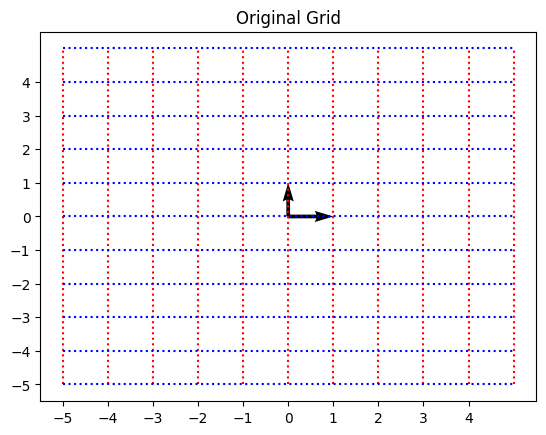

In [44]:
# Showing original grid

def plot_original_grid(T, x, y):
    fig, axes = plt.subplots()
    
    # Original grid
    for i in x:
        plt.plot([i]*len(y), y, linestyle='dotted', color='r') # vertical lines
        # x = [i, i, i, ... 11 times]
    
    for j in y:
        plt.plot(x, [j]*len(x), linestyle='dotted', color='b') # horizontal lines

    e1 = np.array([1, 0])
    e2 = np.array([0, 1])

    plt.quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1)
    plt.quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1)
    
    axes.set_xticks(np.arange(-5, 5, 1))
    axes.set_yticks(np.arange(-5, 5, 1))
    
    plt.title("Original Grid")
    plt.show()

T = np.array([[2, 1],
          [0, 1]])

x = np.linspace(-5, 5, 11)
y = np.linspace(-5, 5, 11)

plot_original_grid(T, x, y)

In [45]:
# Transformed grid - Coding Intuition
T = np.array([[2, 1],
              [0, 1]])

x = np.linspace(-5, 5, 11)
y = np.linspace(-5, 5, 11)

# If x = 5, for that X, all the y's are plotted. Loop is done to put grids like that
pts = np.array([[5, j] for j in y]) 
print(T.shape, pts)

# Transpose is taken - so as to do the transpose
transpose = pts.T 
print('Transpose: \n', transpose)

# Transformation is done with T
transformed = T @ transpose
print('Transformed: \n', transformed)

# Transformed vector is again transposed back for axis in the format (x, y)
transform_Transpose = transformed.T
print('Transform after transposing: \n', transform_Transpose)
print('Transpose the transformed result x axis: \n', transform_Transpose[:, 0])
print('Transpose the transformed result y axis: \n', transform_Transpose[:, 1])

# Here in this example, x is shear + stretch (because new x depends on both x and y) and y stayed same
# x_new = 2x + y and y_new = y

(2, 2) [[ 5. -5.]
 [ 5. -4.]
 [ 5. -3.]
 [ 5. -2.]
 [ 5. -1.]
 [ 5.  0.]
 [ 5.  1.]
 [ 5.  2.]
 [ 5.  3.]
 [ 5.  4.]
 [ 5.  5.]]
Transpose: 
 [[ 5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.]
 [-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.]]
Transformed: 
 [[ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
 [-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.]]
Transform after transposing: 
 [[ 5. -5.]
 [ 6. -4.]
 [ 7. -3.]
 [ 8. -2.]
 [ 9. -1.]
 [10.  0.]
 [11.  1.]
 [12.  2.]
 [13.  3.]
 [14.  4.]
 [15.  5.]]
Transpose the transformed result x axis: 
 [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
Transpose the transformed result y axis: 
 [-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.]


In [50]:
# Plotting Transformed Grid

def plot_transformed_grid(T, x, y):
    for i in x:
        pts = np.array([[i, j] for j in y])
        transformed = (T @ pts.T).T
        plt.plot(transformed[:, 0], transformed[:, 1], linestyle='dotted', color='r')
    
    for j in y:
        pts = np.array([[i, j] for i in x])
        transformed = (T @ pts.T).T
        plt.plot(transformed[ :, 0], transformed[ :, 1], linestyle='dotted', color='b')
    
    e1 = np.array([1, 0])
    e2 = np.array([0, 1])
    
    Te1 = T @ e1
    Te2 = T @ e2
    
    plt.quiver(0, 0, Te1[0], Te1[1], angles='xy', scale_units='xy', scale=1)
    plt.quiver(0, 0, Te2[0], Te2[1], angles='xy', scale_units='xy', scale=1)
    
    plt.axhline(0)
    plt.axvline(0)
    plt.grid()
    plt.gca().set_aspect('equal')
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.title("Full Grid Transformation")
    plt.show()


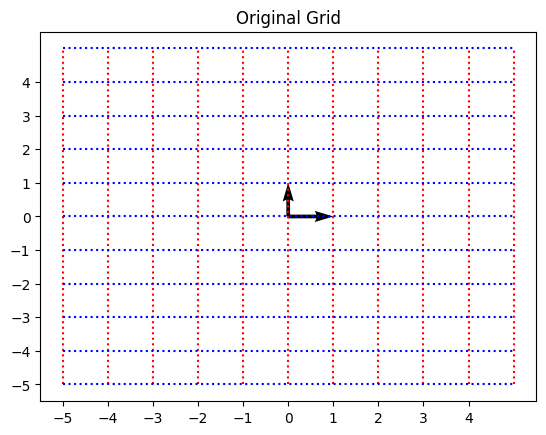

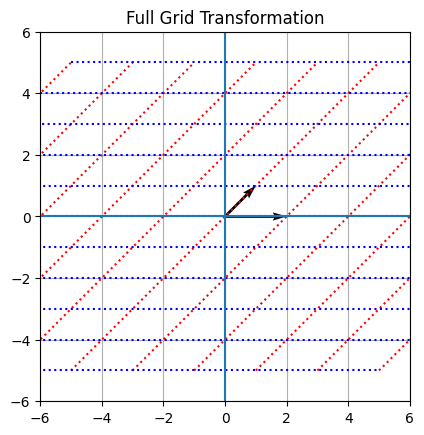

In [51]:
T = np.array([[2, 1],
              [0, 1]])

x = np.linspace(-5, 5, 11)
y = np.linspace(-5, 5, 11)

plot_original_grid(T, x, y)
plot_transformed_grid(T, x, y)

In [52]:
# Identity Matrix

I = np.array([[1, 0], [0, 1]])
print('I @ T: \n', I @ T)
print('T: \n', T)

I @ T: 
 [[2 1]
 [0 1]]
T: 
 [[2 1]
 [0 1]]


T @ T_inv: 
 [[1. 0.]
 [0. 1.]]


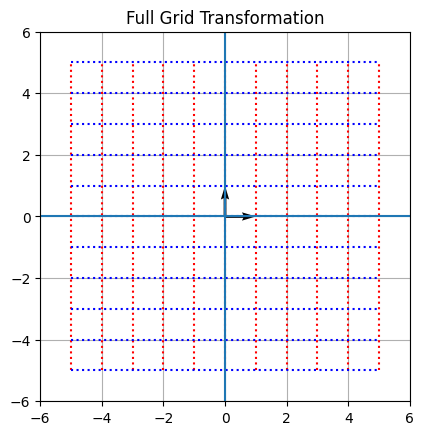

In [55]:
# Inverse matrix

T_inv = np.linalg.inv(T)

Transform = T @ T_inv
print('T @ T_inv: \n', Transform)

plot_transformed_grid(Transform, x, y)